# DarkWeb Traffic Analysis

Runtime Environment

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

Loading Dataset

In [ ]:
file_path = '/content/Darknet.csv'
df = pd.read_csv(file_path)

# Basic Dataset Information
print("Dataset Info:")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158616 entries, 0 to 158615
Data columns (total 85 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Flow ID                     158616 non-null  object 
 1   Src IP                      158616 non-null  object 
 2   Src Port                    158616 non-null  int64  
 3   Dst IP                      158616 non-null  object 
 4   Dst Port                    158616 non-null  int64  
 5   Protocol                    158616 non-null  int64  
 6   Timestamp                   158616 non-null  object 
 7   Flow Duration               158616 non-null  int64  
 8   Total Fwd Packet            158616 non-null  int64  
 9   Total Bwd packets           158616 non-null  int64  
 10  Total Length of Fwd Packet  158616 non-null  int64  
 11  Total Length of Bwd Packet  158616 non-null  int64  
 12  Fwd Packet Length Max       158616 non-null  int64  
 13  

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include='number')
print("Numeric Columns Info:")
print(numeric_df.info())

Numeric Columns Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158616 entries, 0 to 158615
Data columns (total 79 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Src Port                    158616 non-null  int64  
 1   Dst Port                    158616 non-null  int64  
 2   Protocol                    158616 non-null  int64  
 3   Flow Duration               158616 non-null  int64  
 4   Total Fwd Packet            158616 non-null  int64  
 5   Total Bwd packets           158616 non-null  int64  
 6   Total Length of Fwd Packet  158616 non-null  int64  
 7   Total Length of Bwd Packet  158616 non-null  int64  
 8   Fwd Packet Length Max       158616 non-null  int64  
 9   Fwd Packet Length Min       158616 non-null  int64  
 10  Fwd Packet Length Mean      158616 non-null  float64
 11  Fwd Packet Length Std       158616 non-null  float64
 12  Bwd Packet Length Max       158616 non-null  int64

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include='number')
print("Numeric Columns Info:")
print(numeric_df.info())

Numeric Columns Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158616 entries, 0 to 158615
Data columns (total 79 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Src Port                    158616 non-null  int64  
 1   Dst Port                    158616 non-null  int64  
 2   Protocol                    158616 non-null  int64  
 3   Flow Duration               158616 non-null  int64  
 4   Total Fwd Packet            158616 non-null  int64  
 5   Total Bwd packets           158616 non-null  int64  
 6   Total Length of Fwd Packet  158616 non-null  int64  
 7   Total Length of Bwd Packet  158616 non-null  int64  
 8   Fwd Packet Length Max       158616 non-null  int64  
 9   Fwd Packet Length Min       158616 non-null  int64  
 10  Fwd Packet Length Mean      158616 non-null  float64
 11  Fwd Packet Length Std       158616 non-null  float64
 12  Bwd Packet Length Max       158616 non-null  int64

## Data Visualization

### Bar Chart

<ipython-input-5-e12a843533c4>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette='pastel')


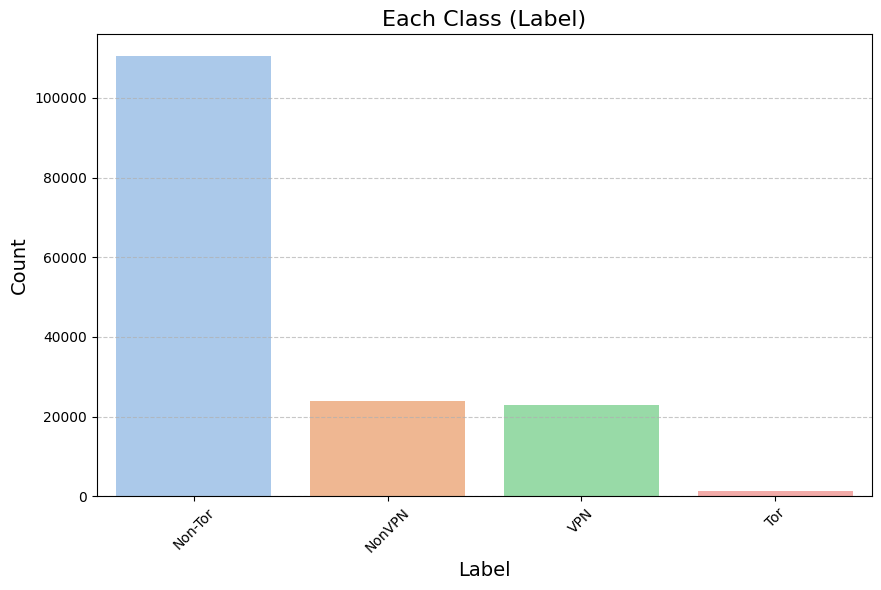

<ipython-input-5-e12a843533c4>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette='pastel')


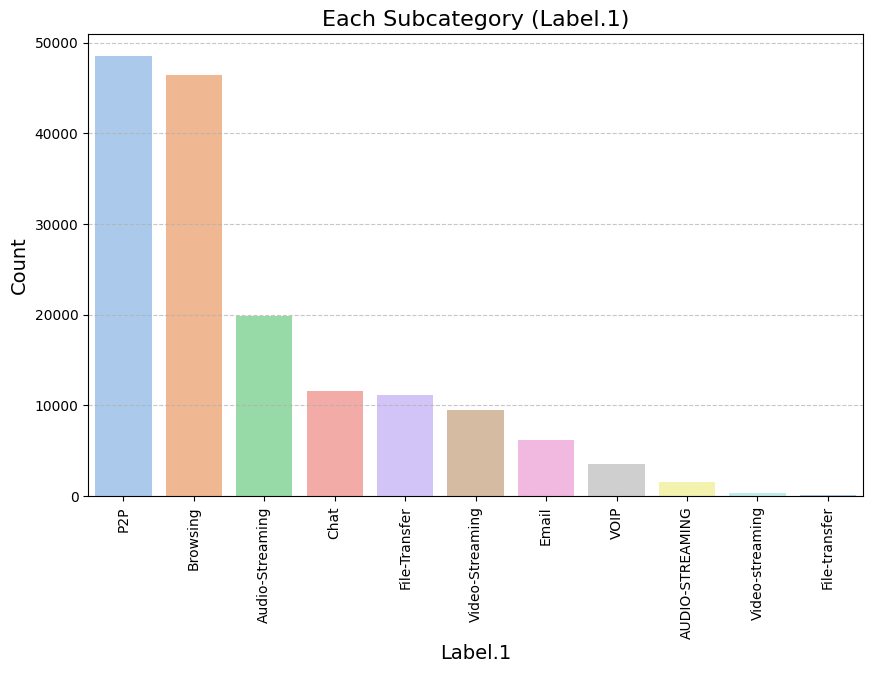

In [ ]:
def plot_bar_chart(column, title, rotation=0, color='skyblue'):
    plt.figure(figsize=(10, 6))
    value_counts = df[column].value_counts()
    sns.barplot(x=value_counts.index, y=value_counts.values, palette='pastel')
    plt.title(title, fontsize=16)
    plt.xlabel(column, fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.xticks(rotation=rotation)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Bar Chart for Label
plot_bar_chart('Label', 'Each Class (Label)', rotation=45, color='lightcoral')

# Bar Chart for Label.1
plot_bar_chart('Label.1', 'Each Subcategory (Label.1)', rotation=90, color='lightgreen')


### Pie Chart

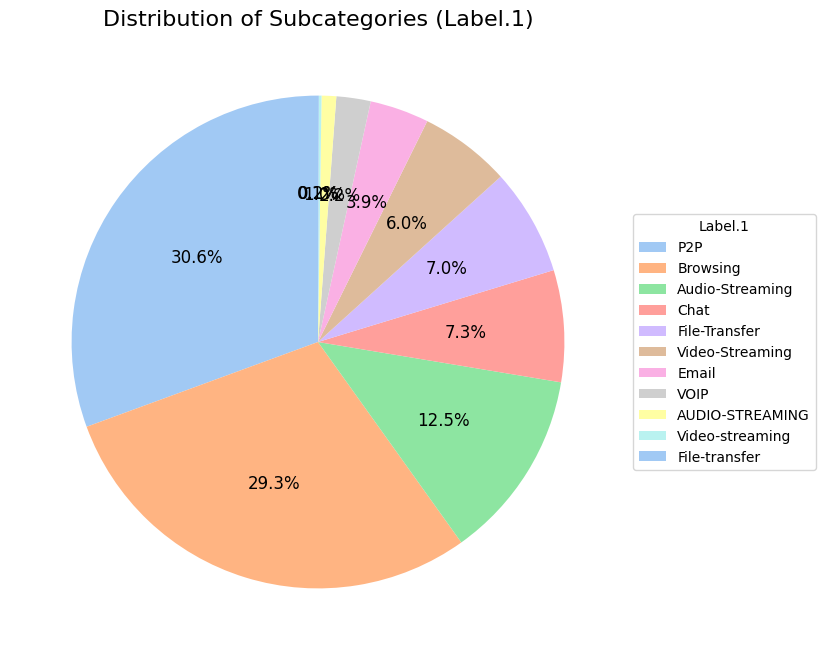

In [ ]:
def plot_pie_chart(column, title):
    plt.figure(figsize=(10, 8))
    label_counts = df[column].value_counts()
    wedges, texts, autotexts = plt.pie(label_counts,
                                       autopct='%1.1f%%',
                                       colors=sns.color_palette('pastel'),
                                       startangle=90,
                                       textprops={'fontsize': 12})

    # Adding legend to avoid overlapping text
    plt.legend(wedges, label_counts.index, title=column, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))
    plt.title(title, fontsize=16)
    plt.show()

plot_pie_chart('Label.1', 'Distribution of Subcategories (Label.1)')


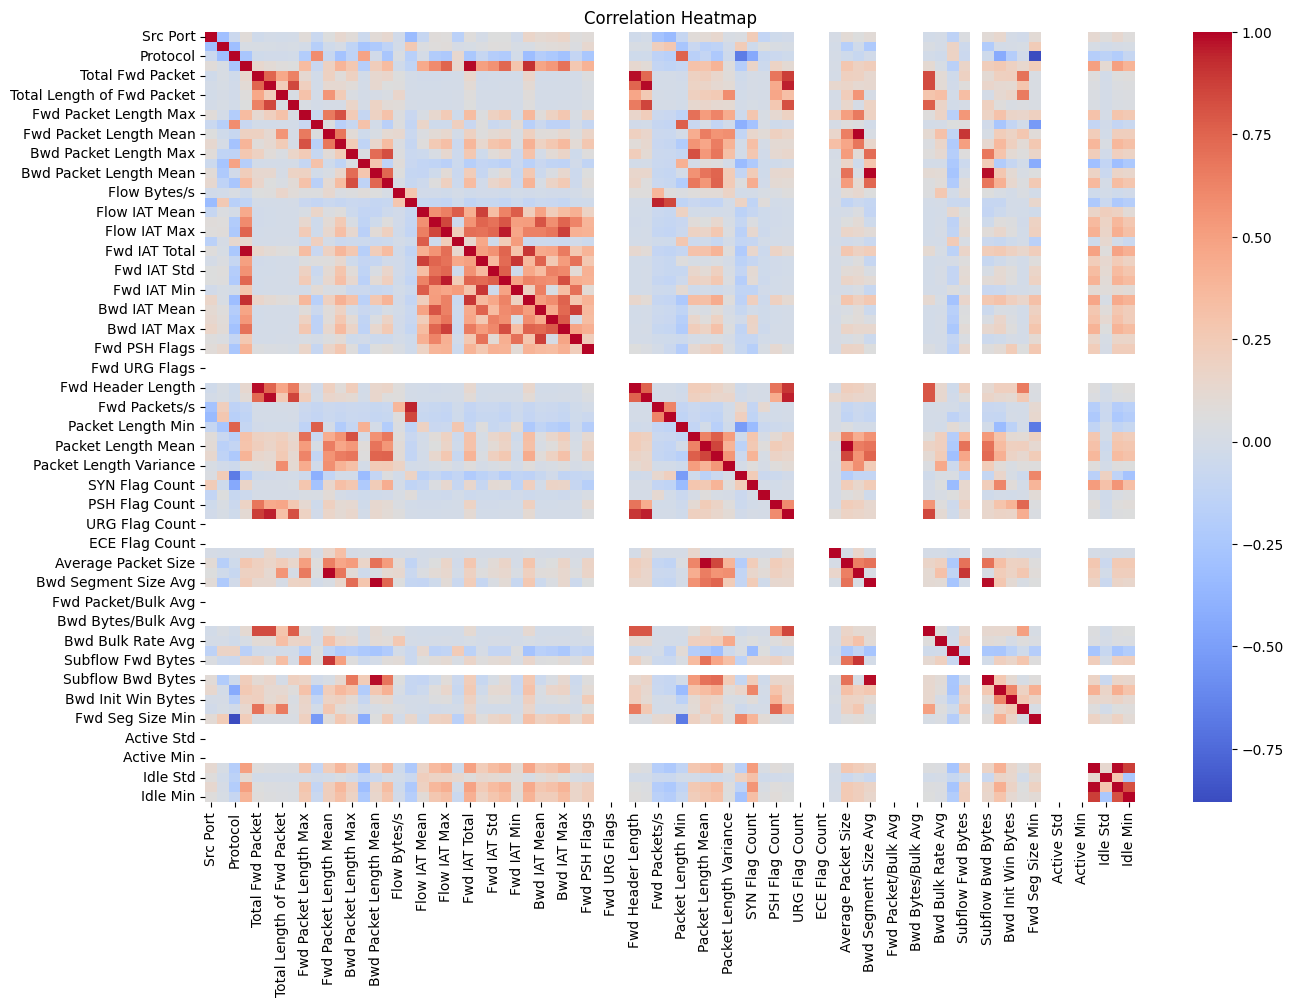

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(15, 10))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Identify highly correlated features
correlation_threshold = 0.85
high_corr_pairs = []

# Loop through the matrix and find pairs with high correlation
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > correlation_threshold:
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            corr_value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((colname_i, colname_j, corr_value))

# Display highly correlated pairs
print("Highly Correlated Feature Pairs (|correlation| > 0.85):")
for pair in high_corr_pairs:
    print(f"{pair[0]} and {pair[1]} -> Correlation: {pair[2]:.2f}")

Highly Correlated Feature Pairs (|correlation| > 0.85):
Total Length of Bwd Packet and Total Bwd packets -> Correlation: 0.85
Flow IAT Max and Flow IAT Std -> Correlation: 0.85
Fwd IAT Total and Flow Duration -> Correlation: 0.99
Fwd IAT Mean and Flow IAT Mean -> Correlation: 0.87
Fwd IAT Max and Flow IAT Max -> Correlation: 0.96
Fwd IAT Min and Fwd IAT Mean -> Correlation: 0.90
Bwd IAT Total and Flow Duration -> Correlation: 0.92
Bwd IAT Total and Fwd IAT Total -> Correlation: 0.90
Bwd IAT Max and Flow IAT Max -> Correlation: 0.87
Bwd IAT Min and Bwd IAT Mean -> Correlation: 0.88
Fwd Header Length and Total Fwd Packet -> Correlation: 0.98
Bwd Header Length and Total Bwd packets -> Correlation: 0.99
Bwd Header Length and Total Length of Bwd Packet -> Correlation: 0.86
Fwd Packets/s and Flow Packets/s -> Correlation: 0.94
Packet Length Std and Packet Length Mean -> Correlation: 0.86
ACK Flag Count and Total Fwd Packet -> Correlation: 0.88
ACK Flag Count and Total Bwd packets -> Correlat

## Data Pre-Processing

### Removing Duplicates

In [ ]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 39004


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates(keep='first')
print(f"New dataset shape after removing duplicates: {df.shape}")

# Recheck for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

New dataset shape after removing duplicates: (119612, 85)
Number of duplicate rows: 0


In [ ]:
# Handle Infinite Values
numeric_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Check for NaN values after replacing infinities
nan_counts = numeric_df.isna().sum()
nan_counts = nan_counts[nan_counts > 0]
print("Columns with NaN Values After Replacing Infinities:")
print(nan_counts)

# Drop rows with NaN values
numeric_df = numeric_df.dropna()

Columns with NaN Values After Replacing Infinities:
Flow Bytes/s      50
Flow Packets/s    50
dtype: int64


### Standardization

In [ ]:
# Standardization
scaler = StandardScaler()
standardized_data = scaler.fit_transform(numeric_df)
standardized_df = pd.DataFrame(standardized_data, columns=numeric_df.columns)

print("Standardized Data Preview:")
print(standardized_df.head(2))

Standardized Data Preview:
   Src Port  Dst Port  Protocol  Flow Duration  Total Fwd Packet  \
0  0.976241 -0.768559  -0.78203      -0.543455         -0.061661   
1  0.976293 -0.768559  -0.78203      -0.543450         -0.061661   

   Total Bwd packets  Total Length of Fwd Packet  Total Length of Bwd Packet  \
0          -0.043666                   -0.032777                   -0.027695   
1          -0.043666                   -0.032777                   -0.027695   

   Fwd Packet Length Max  Fwd Packet Length Min  ...  Fwd Act Data Pkts  \
0              -0.333167              -0.499826  ...          -0.058603   
1              -0.333167              -0.499826  ...          -0.058603   

   Fwd Seg Size Min  Active Mean  Active Std  Active Max  Active Min  \
0          0.591618          0.0         0.0         0.0         0.0   
1          0.591618          0.0         0.0         0.0         0.0   

   Idle Mean  Idle Std  Idle Max  Idle Min  
0  -1.011921 -0.292716 -1.026108 -0.843

In [ ]:
# Check Variance
variance_threshold = 0.01  # threshold
low_variance_columns = standardized_df.var()[standardized_df.var() < variance_threshold].index.tolist()

print(f"Number of Low Variance Columns (Variance < {variance_threshold}): {len(low_variance_columns)}")
print("Low Variance Columns:")
print(low_variance_columns)

Number of Low Variance Columns (Variance < 0.01): 15
Low Variance Columns:
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg', 'Bwd Bytes/Bulk Avg', 'Subflow Bwd Packets', 'Active Mean', 'Active Std', 'Active Max', 'Active Min']


### Feature Reduction

In [ ]:
# Extract columns to drop from already identified high_corr_pairs
columns_to_drop = set([pair[0] for pair in high_corr_pairs])  # Drop the first column in each pair

# Drop Low Variance and Highly Correlated Columns
print(f"Number of Low Variance Columns: {len(low_variance_columns)}")
print(f"Number of Highly Correlated Columns: {len(columns_to_drop)}")

print("Dropping Low Variance and Highly Correlated Columns")
reduced_df = standardized_df.drop(columns=low_variance_columns + list(columns_to_drop))

# Display final column count
print(f"\nNumber of Remaining Columns after Feature Reduction: {len(reduced_df.columns)}")
print("Remaining Columns:", reduced_df.columns.tolist())


Number of Low Variance Columns: 15
Number of Highly Correlated Columns: 22
Dropping Low Variance and Highly Correlated Columns

Number of Remaining Columns after Feature Reduction: 42
Remaining Columns: ['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Min', 'Fwd IAT Std', 'Bwd IAT Mean', 'Bwd IAT Std', 'Fwd PSH Flags', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'Down/Up Ratio', 'Bwd Packet/Bulk Avg', 'Bwd Bulk Rate Avg', 'Subflow Fwd Packets', 'FWD Init Win Bytes', 'Bwd Init Win Bytes', 'Fwd Act Data Pkt

### Encoding

In [ ]:
# Check unique classes in the label column
print("Unique Classes in Label Column:")
print(df['Label'].unique())

# Check class distribution
print("\nClass Distribution:")
print(df['Label'].value_counts())

Unique Classes in Label Column:
['Non-Tor' 'NonVPN' 'Tor' 'VPN']

Class Distribution:
Label
Non-Tor    71651
NonVPN     23863
VPN        22919
Tor         1179
Name: count, dtype: int64


In [ ]:
# Initialize OneHotEncoder for Label and Label.1
encoder = OneHotEncoder(sparse_output=False)

# Perform One-Hot Encoding on Label and Label.1
encoded_labels = encoder.fit_transform(df[['Label', 'Label.1']])

# Convert to DataFrame
encoded_df = pd.DataFrame(encoded_labels, columns=encoder.get_feature_names_out(['Label', 'Label.1']))

# Drop the original label columns and concatenate the encoded labels
df_encoded = pd.concat([df.drop(columns=['Label', 'Label.1']), encoded_df], axis=1)

print("\nOne-Hot Encoded Labels Preview:")
print(encoded_df.head())
print("\nDataset Shape after Encoding:", df_encoded.shape)


One-Hot Encoded Labels Preview:
   Label_Non-Tor  Label_NonVPN  Label_Tor  Label_VPN  Label.1_AUDIO-STREAMING  \
0            1.0           0.0        0.0        0.0                      1.0   
1            1.0           0.0        0.0        0.0                      1.0   
2            1.0           0.0        0.0        0.0                      1.0   
3            1.0           0.0        0.0        0.0                      1.0   
4            1.0           0.0        0.0        0.0                      1.0   

   Label.1_Audio-Streaming  Label.1_Browsing  Label.1_Chat  Label.1_Email  \
0                      0.0               0.0           0.0            0.0   
1                      0.0               0.0           0.0            0.0   
2                      0.0               0.0           0.0            0.0   
3                      0.0               0.0           0.0            0.0   
4                      0.0               0.0           0.0            0.0   

   Label.1_File-T

# Machine Learning Models

In [ ]:
# Step 1: Reset the main DataFrame index
df = df.reset_index(drop=True)
reduced_df = reduced_df.reset_index(drop=True)

# Step 2: Keep only rows that exist in both (take min length)
min_len = min(len(df), len(reduced_df))
X = reduced_df.iloc[:min_len].copy()
y = df.loc[:min_len - 1, 'Label'].copy()

# Step 3: Encode target labels (TOR, Non-TOR, etc.)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, stratify=y_encoded, test_size=0.2, random_state=42
)

# Step 5: Train models
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

# Step 6: Evaluation
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))
print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))
print("\n=== SVM ===")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

=== Logistic Regression ===
              precision    recall  f1-score   support

     Non-Tor       0.74      0.87      0.80     14330
      NonVPN       0.51      0.52      0.51      4773
         Tor       0.00      0.00      0.00       236
         VPN       0.75      0.36      0.49      4584

    accuracy                           0.70     23923
   macro avg       0.50      0.44      0.45     23923
weighted avg       0.69      0.70      0.68     23923


=== Random Forest ===
              precision    recall  f1-score   support

     Non-Tor       0.81      0.81      0.81     14330
      NonVPN       0.34      0.36      0.35      4773
         Tor       0.00      0.00      0.00       236
         VPN       0.88      0.84      0.86      4584

    accuracy                           0.72     23923
   macro avg       0.51      0.50      0.50     23923
weighted avg       0.72      0.72      0.72     23923


=== SVM ===
              precision    recall  f1-score   support

     Non-To

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Step 1: Reset the main DataFrame index
df = df.reset_index(drop=True)
reduced_df = reduced_df.reset_index(drop=True)

# Step 2: Keep only rows that exist in both (take min length)
min_len = min(len(df), len(reduced_df))
X = reduced_df.iloc[:min_len].copy()
y = df.loc[:min_len - 1, 'Label'].copy()

# Step 3: Encode target labels (TOR, Non-TOR, etc.)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Step 4: Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, stratify=y_encoded, test_size=0.2, random_state=42
)

# Step 5: Train models with class weights
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

svm = SVC(class_weight='balanced')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

# Step 6: Evaluation
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))
print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))
print("\n=== SVM ===")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

=== Logistic Regression ===
              precision    recall  f1-score   support

     Non-Tor       0.88      0.62      0.73     14330
      NonVPN       0.47      0.57      0.52      4773
         Tor       0.06      0.89      0.11       236
         VPN       0.52      0.48      0.50      4584

    accuracy                           0.59     23923
   macro avg       0.48      0.64      0.46     23923
weighted avg       0.72      0.59      0.64     23923


=== Random Forest ===
              precision    recall  f1-score   support

     Non-Tor       0.81      0.80      0.81     14330
      NonVPN       0.35      0.38      0.36      4773
         Tor       0.01      0.01      0.01       236
         VPN       0.87      0.84      0.85      4584

    accuracy                           0.72     23923
   macro avg       0.51      0.51      0.51     23923
weighted avg       0.72      0.72      0.72     23923


=== SVM ===
              precision    recall  f1-score   support

     Non-To

# Evaluation

=== Model Evaluation Summary ===


,Model,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.5907,0.5891,0.4805,0.6418,0.4635
1,Random Forest,0.8825,0.7157,0.5116,0.5067,0.5088
2,SVM,0.7003,0.6998,0.5687,0.7249,0.5523


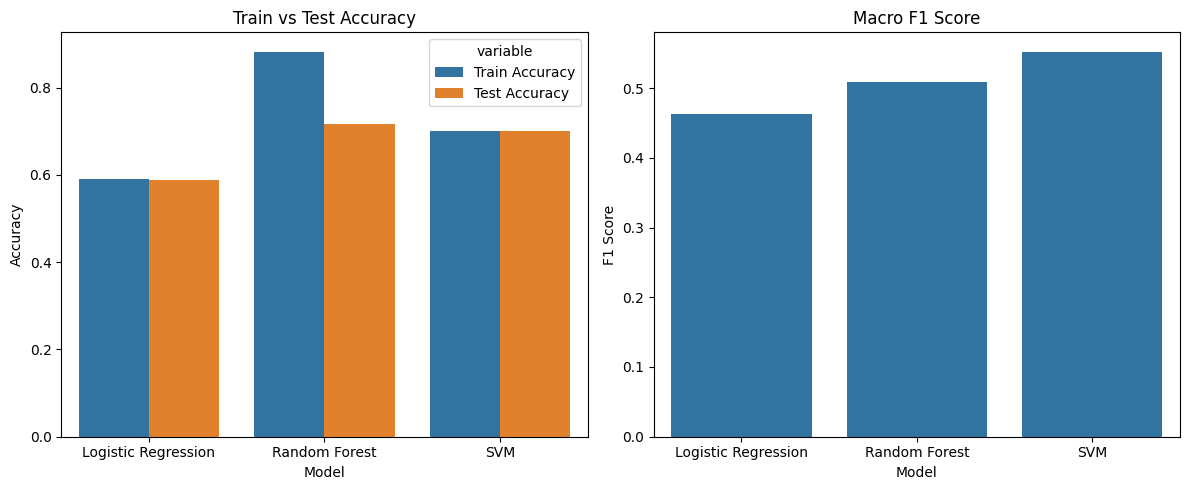

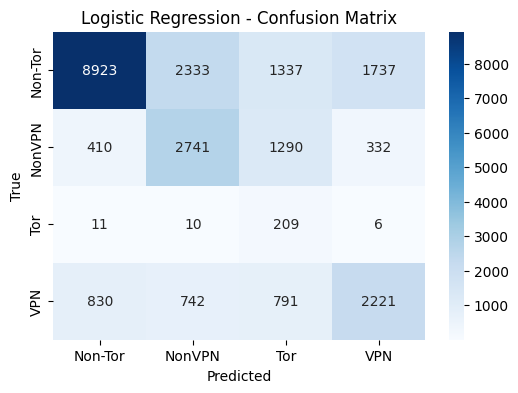

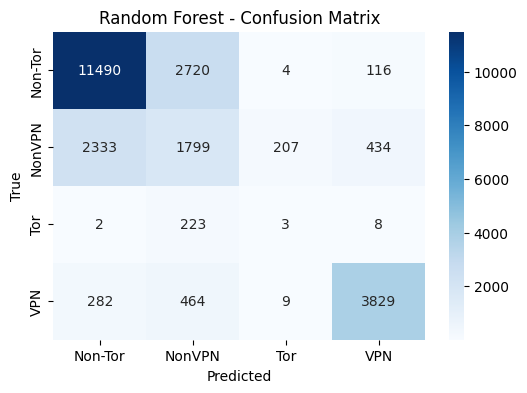

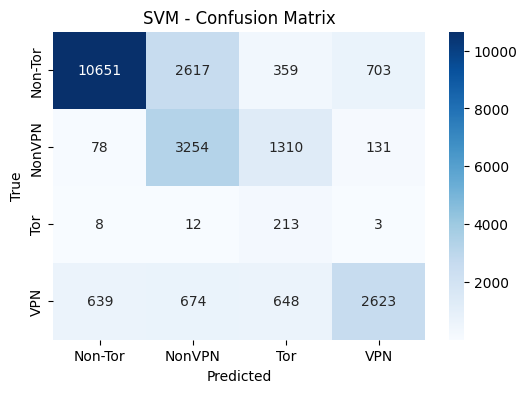

In [ ]:
# Step 1: Accuracy
lr_train_acc = accuracy_score(y_train, lr.predict(X_train))
lr_test_acc = accuracy_score(y_test, y_pred_lr)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc = accuracy_score(y_test, y_pred_rf)

svm_train_acc = accuracy_score(y_train, svm.predict(X_train))
svm_test_acc = accuracy_score(y_test, y_pred_svm)

# Step 2: Macro Precision, Recall, F1
def get_macro_avg(report):
    return {
        'precision': report['macro avg']['precision'],
        'recall': report['macro avg']['recall'],
        'f1': report['macro avg']['f1-score']
    }

lr_report = classification_report(y_test, y_pred_lr, target_names=le.classes_, output_dict=True)
rf_report = classification_report(y_test, y_pred_rf, target_names=le.classes_, output_dict=True)
svm_report = classification_report(y_test, y_pred_svm, target_names=le.classes_, output_dict=True)

# Step 3: Summary Table
summary_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Train Accuracy': [lr_train_acc, rf_train_acc, svm_train_acc],
    'Test Accuracy': [lr_test_acc, rf_test_acc, svm_test_acc],
    'Macro Precision': [get_macro_avg(lr_report)['precision'], get_macro_avg(rf_report)['precision'], get_macro_avg(svm_report)['precision']],
    'Macro Recall': [get_macro_avg(lr_report)['recall'], get_macro_avg(rf_report)['recall'], get_macro_avg(svm_report)['recall']],
    'Macro F1': [get_macro_avg(lr_report)['f1'], get_macro_avg(rf_report)['f1'], get_macro_avg(svm_report)['f1']]
})

print("=== Model Evaluation Summary ===")
display(summary_df.round(4))

# Step 4: Bar Plots
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='value', hue='variable',
            data=pd.melt(summary_df[['Model', 'Train Accuracy', 'Test Accuracy']], ['Model']))
plt.title('Train vs Test Accuracy')
plt.ylabel('Accuracy')

# Macro F1 Plot
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='Macro F1', data=summary_df)
plt.title('Macro F1 Score')
plt.ylabel('F1 Score')

plt.tight_layout()
plt.show()

# Step 5: Confusion Matrices
models = {'Logistic Regression': y_pred_lr, 'Random Forest': y_pred_rf, 'SVM': y_pred_svm}

for name, y_pred in models.items():
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
